In [1]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

def standardise(col):
    return (col - col.mean()) / col.std()

# Load, Process, Align Dates

In [3]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Get Brent data
name=r'commodities_data_v0.xlsx'
brent = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
brent.index = pd.to_datetime(brent.index) # - TTF Nat Gas Spot; USD (assumed)
brent = clean_process(brent)

# Get TTF data - EUR
name=r'ttf_front_month.xlsx'
ttf = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
ttf.index = pd.to_datetime(ttf.index) # - TTF Nat Gas Spot; USD (assumed)
ttf = clean_process(ttf)

# Load Utilities Equity Data - 'SX6P Index' is STOXX600 European Utilities; EUR
name=r'utilities_data_v0.xlsx'
utilities_equity=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )
utilities_equity.index = pd.to_datetime(utilities_equity.index)     # - Ensure datatime indexation
utilities_equity = clean_process(utilities_equity)

# Utility debt yield index data (10Y)
name=r'utilities_debt.xlsx'
util_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,3],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals  
util_yield_10y.index = pd.to_datetime(util_yield_10y.index)     # - Ensure datatime indexation
util_yield_10y = clean_process(util_yield_10y)

# Get EUR curve data (10Y)
name=r'euro_curve.xlsx'
govt_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals
govt_yield_10y.index = pd.to_datetime(govt_yield_10y.index)     # - Ensure datatime indexation
govt_yield_10y = clean_process(govt_yield_10y)

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time ax

In [4]:
utilities_equity

,SX6P Index
Date,
2005-01-03,273.730000
2005-01-04,274.030000
2005-01-05,274.760000
2005-01-06,274.930000
2005-01-07,276.240000
...,...
2025-11-09,569.526667
2025-11-10,569.580000
2025-11-11,567.060000


# Duration Assumptions, Convert to Log-Returns, Combine

In [5]:
# Convert util yields to returns
# Utility duration will be higher than Govt duration 

D_util = 7.5
D_govt = 8.5

R_util_debt = np.log((1-D_util * util_yield_10y.diff()).dropna() )
R_govt = np.log((1-D_govt * govt_yield_10y.diff()).dropna() )

R_util_eqty = np.log((1+utilities_equity.diff() / utilities_equity.shift(1)).dropna() )
R_brent = np.log((1+brent.diff() / brent.shift(1)).dropna() )
R_ttf = np.log((1+ttf.diff() / ttf.shift(1)).dropna() )

df = merge_dfs([R_brent, R_ttf, R_util_eqty, R_util_debt, R_govt]).dropna()

# Resample frequency 
df = df.resample('30D').last()

print(df.head(5))

            CO1 Comdty  TTF_front_month  SX6P Index  IGEEUA10 BVLI Index  \
2011-04-30   -0.001016         0.000826   -0.002397            -0.000073   
2011-05-30    0.025983        -0.002057   -0.000852            -0.004390   
2011-06-29   -0.000596        -0.000161   -0.021294            -0.000045   
2011-07-29    0.001555         0.005316   -0.006098            -0.002185   
2011-08-28   -0.000096        -0.000184   -0.012076             0.001259   

                 10Y  
2011-04-30  0.000582  
2011-05-30 -0.000252  
2011-06-29  0.000823  
2011-07-29  0.000824  
2011-08-28  0.000544  


# Regime Identification & Standardisation

In [6]:
mu_p_6m_brent = brent.rolling(window=180).mean().dropna()
std_p_6m_brent = brent.rolling(window=180).std().dropna()
threshold_brent = mu_p_6m_brent + 1.5*std_p_6m_brent

mu_p_6m_ttf = ttf.rolling(window=180).mean().dropna()
std_p_6m_ttf = ttf.rolling(window=180).std().dropna()
threshold_ttf = mu_p_6m_ttf + 1.5*std_p_6m_ttf

# threshold will be shorter than brent due to rolling calculation
indicator_brent=pd.Series(data=np.where(brent['CO1 Comdty'].loc[threshold_brent.index] > threshold_brent['CO1 Comdty'], 1, 0), index=threshold_brent.index)
indicator_ttf=pd.Series(data=np.where(ttf['TTF_front_month'].loc[threshold_ttf.index] > threshold_ttf['TTF_front_month'], 1, 0), index=threshold_ttf.index)


# crop indicator to fit into df
indicator_brent = indicator_brent[indicator_brent.index.isin(df.index)]
indicator_ttf = indicator_ttf[indicator_ttf.index.isin(df.index)]
df['D_brent']=indicator_brent
df['D_ttf']=indicator_ttf

df['govt_indic_brent'] = df['D_brent'] * df['10Y']
df['brent_indic_brent'] = df['D_brent'] * df['CO1 Comdty']

df['govt_indic_ttf'] = df['D_ttf'] * df['10Y']
df['brent_indic_ttf'] = df['D_ttf'] * df['TTF_front_month']

# Standardise all columns to make coefficients comparable
df=df.apply(lambda col: standardise(col), axis=0)

df['excess_R_util'] = df['IGEEUA10 BVLI Index'] - df['10Y']

# Target Definition Selection for regressions
# target = ['IGEEUA10 BVLI Index']
target = ['excess_R_util']

df.head(15)

,CO1 Comdty,TTF_front_month,SX6P Index,IGEEUA10 BVLI Index,10Y,D_brent,D_ttf,govt_indic_brent,brent_indic_brent,govt_indic_ttf,brent_indic_ttf,excess_R_util
2011-04-30,-0.013923,0.145470,-0.302486,-0.050400,1.022387,2.525989,-0.571414,3.354387,-0.188930,0.100084,-0.075929,-1.072787
2011-05-30,1.561480,-0.342763,-0.129208,-1.916062,-0.417915,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-1.498147
2011-06-29,0.010555,-0.021808,-2.421956,-0.038515,1.439980,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-1.478495
2011-07-29,0.136103,0.905763,-0.717598,-0.963276,1.441053,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-2.404329
2011-08-28,0.039735,-0.025572,-1.388081,0.525104,0.957264,-0.393661,1.740214,0.071185,-0.042180,1.746292,-0.131808,-0.432161
2011-09-27,-1.021746,-0.218223,-0.218771,1.259297,-0.726064,-0.393661,1.740214,0.071185,-0.042180,-1.203246,-0.478198,1.985361
2011-10-27,-0.706599,-0.383116,0.495077,-2.789395,-2.445977,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-0.343419
2011-11-26,0.221558,-0.390183,0.674244,-0.126040,2.605059,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-2.731098
2011-12-26,-0.245602,0.155975,1.719737,-0.635327,0.389401,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,-1.024729
2012-01-25,0.386199,0.334777,0.802593,1.136479,0.225344,-0.393661,-0.571414,0.071185,-0.042180,0.100084,-0.075929,0.911135


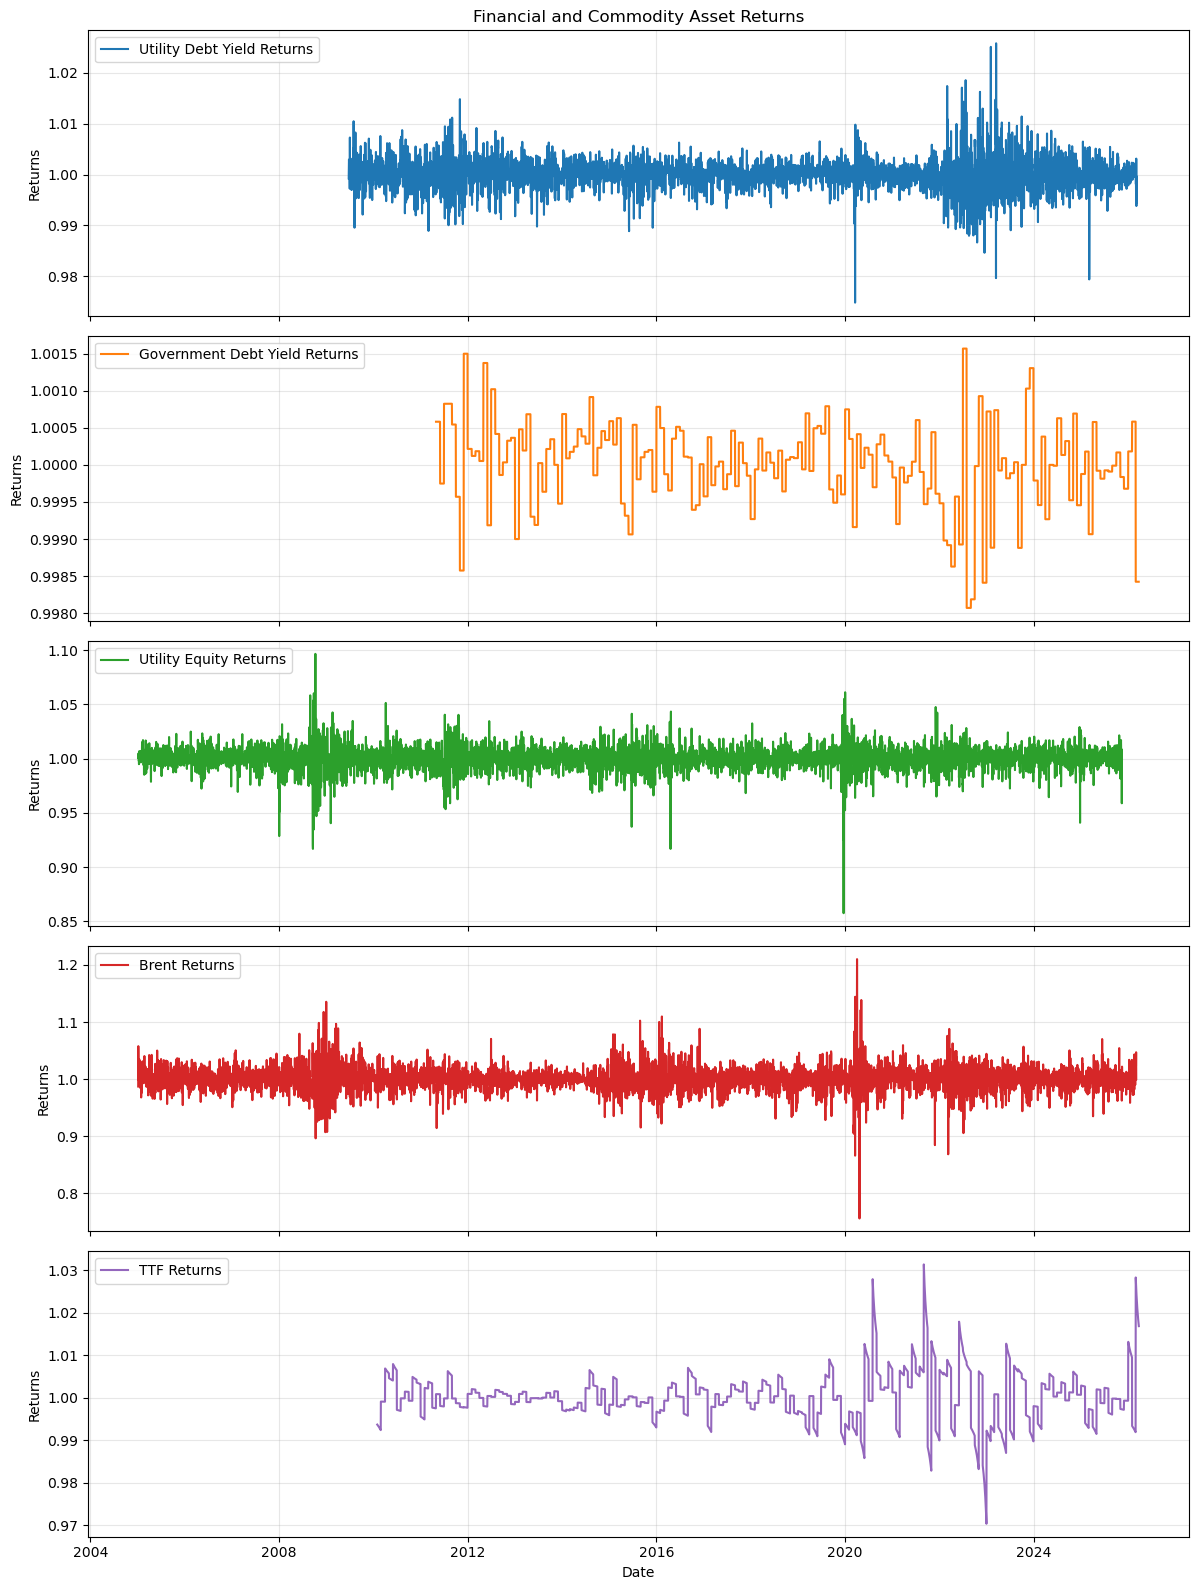

In [ ]:
series_to_plot = {
    'Utility Debt Yield Returns': (1 - D_util * util_yield_10y.diff()).dropna(),
    'Government Debt Yield Returns': (1 - D_govt * govt_yield_10y.diff()).dropna(),
    'Utility Equity Returns': (1 + utilities_equity.pct_change()).dropna(),
    'Brent Returns': (1 + brent.pct_change()).dropna(),
    'TTF Returns': (1 + ttf.pct_change()).dropna()
}

fig, axes = plt.subplots(nrows=len(series_to_plot), ncols=1, figsize=(12, 16), sharex=True)

for i, (label, data) in enumerate(series_to_plot.items()):
    axes[i].plot(data, label=label, color=f'C{i}') # C0, C1, etc. gives distinct colors
    axes[i].set_ylabel('Returns')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Financial and Commodity Asset Returns (Non-processed)')
plt.xlabel('Date')
plt.tight_layout() # Prevents labels from overlapping
plt.show()

# Baseline Unconditional Hedge Model

In [8]:
unconditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','CO1 Comdty', 'SX6P Index']]
        )
        ).fit(cov_type='HC3')

print(unconditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     40.85
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           4.89e-20
Time:                        17:15:30   Log-Likelihood:                -251.35
No. Observations:                 178   AIC:                             510.7
Df Residuals:                     174   BIC:                             523.4
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.388e-17      0.078   1.78e-16      1.0

In [9]:
unconditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','TTF_front_month', 'SX6P Index']]
        )
        ).fit(cov_type='HC3')
print(unconditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     37.46
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           9.97e-19
Time:                        17:15:31   Log-Likelihood:                -248.70
No. Observations:                 178   AIC:                             505.4
Df Residuals:                     174   BIC:                             518.1
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.388e-17      0.077   1.

# Conditional Hedge Model

In [10]:
conditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_brent', 'CO1 Comdty', 'brent_indic_brent', 'D_brent', 'SX6P Index']]
        ),
        ).fit(cov_type='HC3')
print(conditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.475
Model:                            OLS   Adj. R-squared:                  0.457
Method:                 Least Squares   F-statistic:                     22.78
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.19e-19
Time:                        17:15:32   Log-Likelihood:                -248.45
No. Observations:                 178   AIC:                             510.9
Df Residuals:                     171   BIC:                             533.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.388e-17      0.07

In [11]:
conditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_ttf', 'TTF_front_month', 'brent_indic_ttf', 'D_ttf', 'SX6P Index']]
        ),
        ).fit(cov_type='HC3')
print(conditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.481
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     21.48
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           9.97e-19
Time:                        17:15:33   Log-Likelihood:                -247.48
No. Observations:                 178   AIC:                             509.0
Df Residuals:                     171   BIC:                             531.2
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.388e-17      0.078   1.

# Hedge Effectiveness

In [12]:
HE_unconditional_brent = unconditional_model_brent.rsquared
HE_conditional_brent = conditional_model_brent.rsquared

print(f"Brent: Unconditional HE: {HE_unconditional_brent:.4f}")
print(f"Brent: Conditional HE: {HE_conditional_brent:.4f}")

Brent: Unconditional HE: 0.4576
Brent: Conditional HE: 0.4750


In [13]:
HE_unconditional_ttf = unconditional_model_ttf.rsquared
HE_conditional_ttf = conditional_model_ttf.rsquared

print(f"TTF: Unconditional HE: {HE_unconditional_ttf:.4f}")
print(f"TTF: Conditional HE: {HE_conditional_ttf:.4f}")

TTF: Unconditional HE: 0.4735
TTF: Conditional HE: 0.4807
